# Tutorial 09 — LLI/LAM from Fielddata

This tutorial shows the **usage** of the Fielddata pipeline.


**Workflow:**

```
Load CSV  →  30-day chunks  →  consensus pair (fit_real_data)
     →  per-chunk evaluation (evaluate_chunks)  →  SOH trend  →  LLI/LAM time series
```


## Step 0 — Imports and tuning parameters

The pipeline consists of four building blocks — and a block of tuning parameters that
control all filtering decisions:

| Constant | Effect |
|-----------|---------|
| `NROWS` | only load the first n CSV rows (`None` = everything) — for testing |
| `WINDOW_DAYS` | length of a time window; smaller = finer time resolution, but fewer anchors per window |
| `MIN_PAUSE_S` | minimum duration of a rest pause for an OCV anchor (field: better to choose long, the anchors should be fully relaxed) |
| `MIN_POINTS_PER_CHUNK` | windows with fewer anchors are skipped |
| `MAX_RMSE_MV` | quality gate: windows whose *best* fit is worse count as a broken OCV cloud |
| `MIN_DSOC_PAIR` | minimum SOC swing of an anchor pair in the capacity determination |
| `MAX_CYCLING_RATIO` | discards pairs between which a lot of back-and-forth charging occurred |
| `SOC_COVERAGE_MIN` | minimum SOC coverage for a chunk to contribute to determining the common window |
| `CAP_MAD_K` | strictness of the capacity outlier filter (smaller = stricter) |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import pydpeet as eet

from pydpeet.process.analyze.extract.field_data_loader import (
    load_field_data_csv,    # Field CSV (vin schema) -> PyDPEET column schema
    split_by_time_window,   # time series -> time-window chunks
)
from pydpeet.process.analyze.extract.fit_real_data import (
    fit_real_data,          # consensus electrode pair across all chunks
    evaluate_chunks,        # per-chunk pipeline: fit, capacity, plausibility
)
from pydpeet.process.analyze.extract.lli_lam import calculate_lli_lam

eet.set_logging_style("ERROR")

CSV_PATH = "../../../input_data/Felddaten/vin38.csv"

NROWS                = None     # None = whole file; for testing e.g. 500_000
WINDOW_DAYS          = 30
MIN_PAUSE_S          = 600
MIN_POINTS_PER_CHUNK = 20
MAX_RMSE_MV          = 50.0
MIN_DSOC_PAIR        = 0.02
MAX_CYCLING_RATIO    = 2.0
SOC_COVERAGE_MIN     = 0.60
CAP_MAD_K            = 3.0

## Step 1 — Load Fielddata

`load_field_data_csv` converts the logger CSV (vin schema: `terminaltime`, `soc`,
`totalcurrent`, `batteryvoltage`, …) into the PyDPEET column schema (`Test_Time[s]`,
`Voltage[V]`, `Current[A]`, `SOC`, …) — after that, all existing extraction functions
work unchanged. For Parquet sources there is an analogous `load_field_data`.

Useful parameters:

| Parameter | Purpose |
|-----------|-------|
| `nrows` | only load an initial excerpt (fast testing) |
| `cell_voltage_method` | `"cells_mean"` (mean of all individual cells, accurate) or `"minmax_avg"` (much faster, slight bias) |
| `invert_current_sign` | flip current sign if the source uses the reversed charge/discharge convention |
| `soc_scale` | scaling of the source SOC (default 0.01: percent → fraction 0…1) |
| `start_time_s`, `end_time_s` | excerpt in seconds of `terminaltime` |

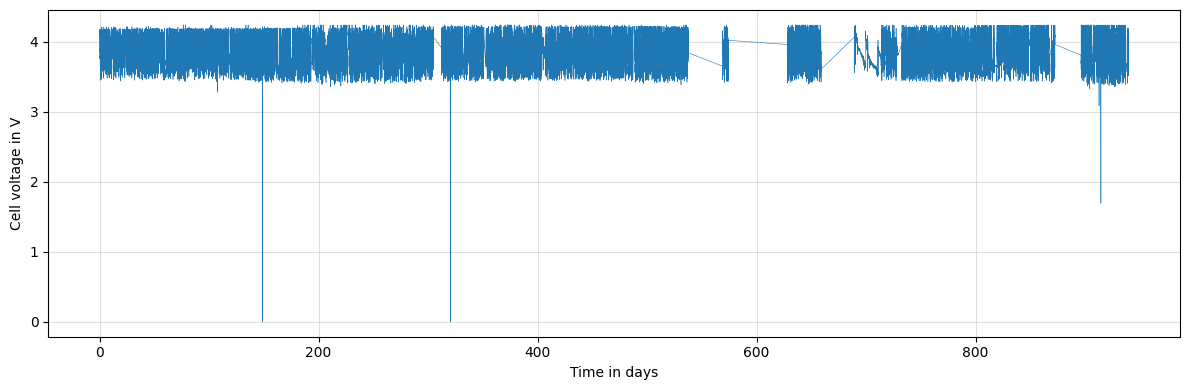

In [2]:
#df_field = load_field_data_csv(CSV_PATH, nrows=NROWS)
#print(f"Loaded: {len(df_field):,} samples, {df_field['Test_Time[s]'].iloc[-1]/86400:.0f} days, "
#      f"SOC {df_field['SOC'].min():.2f} … {df_field['SOC'].max():.2f}")
df_field = eet.read(config="field_data_csv", input_path=CSV_PATH, keep_all_additional_data=True)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_field["Test_Time[s]"] / 86400, df_field["Voltage[V]"], lw=0.4, color="tab:blue")
ax.set_xlabel("Time in days")
ax.set_ylabel("Cell voltage in V")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## Step 2 — Split into time windows

`split_by_time_window` cuts the time series into consecutive windows of
`WINDOW_DAYS` days. Each chunk is later treated as one aging state.


In [3]:
chunks = split_by_time_window(df_field, window_days=WINDOW_DAYS)
print(f"{len(chunks)} chunks of {WINDOW_DAYS} days")

32 chunks of 30 days


## Step 3 — Find the consensus electrode pair

`fit_real_data` performs the chemistry identification in a single call. Internally, for
each chunk: rest pauses → OCV anchors → library grid search over all electrode pairs,
then windows with too poor a "best" fit are discarded (`max_rmse_mv`) and the pairs are
ranked by their **median RMSE across all retained windows**. Row 1 is the consensus pair.

Output columns:

| Column | Meaning |
|--------|---------|
| `Anode`, `Cathode` | file names of the reference half-cells |
| `n_chunks` | in how many retained windows the pair was fittable |
| `median_rmse`, `mean_rmse`, `max_rmse` | fit quality across the windows in mV |
| `wins` | in how many windows the pair was the best fit |

Further options: `sort_by` (`"median"`, `"mean"`, `"wins"`), a custom library via
`anodes_dir`/`cathodes_dir`, `max_workers` (fits run in parallel)


In [ ]:
consensus = fit_real_data(
    df_field,
    window_days=WINDOW_DAYS,
    min_pause_duration_s=MIN_PAUSE_S,
    min_points=MIN_POINTS_PER_CHUNK,
    max_rmse_mv=MAX_RMSE_MV,
)

top = consensus.iloc[0]
print(f"\nConsensus pair: {top['Anode']}  +  {top['Cathode']}  "
      f"(median RMSE {top['median_rmse']:.1f} mV over {top['n_chunks']} chunks, {top['wins']} wins)")
consensus.head(5).round(2)

## Step 4 — Per-chunk evaluation against the fixed pair

`evaluate_chunks` evaluates each chunk against the consensus pair.



Important entries in the returned dictionary:

| Key | Content |
|-----|--------|
| `overview` | finished overview table (one row per chunk) |
| `soh_ids` | chunk indices that survived all filters |
| `cap_per_chunk_mAh`, `cap_ref_mAh` | capacity per chunk and SOH reference (median of the first plausible chunks) |
| `quantities_per_chunk` | electrode quantities per chunk — input for `calculate_lli_lam` |
| `global_window` | common SOC window used |


In [ ]:
res = evaluate_chunks(
    chunks, top["Anode"], top["Cathode"],
    min_pause_duration_s=MIN_PAUSE_S,
    min_points=MIN_POINTS_PER_CHUNK,
    max_rmse_mv=MAX_RMSE_MV,
    min_dsoc_pair=MIN_DSOC_PAIR,
    max_cycling_ratio=MAX_CYCLING_RATIO,
    soc_coverage_min=SOC_COVERAGE_MIN,
    cap_mad_k=CAP_MAD_K,
)

res["overview"]


## Step 5 — SOH trend

.

In [ ]:
soh_ids = res["soh_ids"]
soh_pct = [res["cap_per_chunk_mAh"][i] / res["cap_ref_mAh"] * 100 for i in soh_ids]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(soh_ids, soh_pct, "o-", color="tab:red", label="SOH per chunk")
ax.axhline(100, color="0.6", lw=0.7, ls="--", label="100 % (reference)")
ax.set_xlabel(f"Chunk index ({WINDOW_DAYS}-day windows)")
ax.set_ylabel("SOH in %")
ax.grid(True, alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

## Step 6 — LLI/LAM time series

`calculate_lli_lam` compares the electrode quantities of two chunks. The evaluation is
**cumulative**: each plausible chunk against the first plausible chunk — this yields the
total degradation since the start of observation.

For interpretation, the same applies as in the CheckUp case: positive values = loss, LAM
is less certain than SOH and LLI (window identification on partial coverage).

In [ ]:
quantities = res["quantities_per_chunk"]
cols = ["ref_chunk", "chunk", "SOH_pct", "LLI_pct", "LAM_Anode_pct", "LAM_Cathode_pct"]

if len(soh_ids) < 2:
    print(f"Only {len(soh_ids)} plausible chunk — at least 2 are needed for an LLI/LAM time series.")
else:
    ref0 = soh_ids[0]
    kumulativ = pd.concat(
        [calculate_lli_lam(quantities[ref0], quantities[c]).assign(ref_chunk=ref0, chunk=c)
         for c in soh_ids[1:]],
        ignore_index=True,
    )
    print(f"Cumulative (vs. chunk {ref0}):")
    print(kumulativ[cols].round(2).to_string(index=False))

In [ ]:
if len(soh_ids) >= 2:
    x = kumulativ["chunk"].to_numpy()
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(x, kumulativ["LLI_pct"],         "o-", color="tab:blue",   label="LLI")
    ax.plot(x, kumulativ["LAM_Anode_pct"],   "s-", color="tab:orange", label="LAM Anode")
    ax.plot(x, kumulativ["LAM_Cathode_pct"], "^-", color="tab:green",  label="LAM Cathode")
    ax.axhline(0, color="0.5", lw=0.6)
    ax.set_xlabel(f"Chunk index ({WINDOW_DAYS}-day windows)")
    ax.set_ylabel(f"cumulative loss in %  (vs. chunk {soh_ids[0]})")
    ax.grid(True, alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plt.show()